## import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

## Data Preparation

In [2]:
data=pd.read_csv(r"C:\Users\HP\Desktop\car_sales_2018_2024_enhanced.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59977 entries, 0 to 59976
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               59977 non-null  object 
 1   Salesperson        59977 non-null  object 
 2   Customer Name      59977 non-null  object 
 3   Customer Age       59977 non-null  int64  
 4   Customer Gender    59977 non-null  object 
 5   Car Make           59977 non-null  object 
 6   Car Model          59977 non-null  object 
 7   Car Year           59977 non-null  int64  
 8   Quantity           59977 non-null  int64  
 9   Sale Price         59977 non-null  float64
 10  Cost               59976 non-null  float64
 11  Profit             59976 non-null  float64
 12  Discount           59976 non-null  float64
 13  Payment Method     59976 non-null  object 
 14  Commission Rate    59976 non-null  float64
 15  Commission Earned  59976 non-null  float64
 16  Sales Region       599

In [ ]:
data.columns

Index(['Date', 'Salesperson', 'Customer Name', 'Customer Age',
       'Customer Gender', 'Car Make', 'Car Model', 'Car Year', 'Quantity',
       'Sale Price', 'Cost', 'Profit', 'Discount', 'Payment Method',
       'Commission Rate', 'Commission Earned', 'Sales Region', 'Sale Year',
       'Sale Month', 'Sale Quarter', 'Day of Week', 'Season'],
      dtype='object')

In [ ]:
data.isna().sum()

,0
Date,0
Salesperson,0
Customer Name,0
Customer Age,0
Customer Gender,0
Car Make,0
Car Model,0
Car Year,0
Quantity,0
Sale Price,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.dtypes

,0
Date,object
Salesperson,object
Customer Name,object
Customer Age,int64
Customer Gender,object
Car Make,object
Car Model,object
Car Year,int64
Quantity,int64
Sale Price,float64


#### data cleaning

In [ ]:
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

numeric_cols = ['Customer Age', 'Car Year', 'Quantity', 'Sale Price',
                'Cost', 'Profit', 'Discount', 'Commission Rate',
                'Sale Year', 'Sale Quarter']
data[numeric_cols] = data[numeric_cols].apply(pd.to_numeric, errors='coerce')

categorical_cols = ['Salesperson', 'Customer Gender', 'Car Make',
                    'Car Model', 'Payment Method', 'Sales Region',
                    'Sale Month', 'Day of Week', 'Season']
for col in categorical_cols:
    data[col] = data[col].astype('category')


data = data.drop(columns=['Customer Name', 'Commission Earned'])

data = data.dropna(subset=['Sale Price', 'Date'])
data = data.fillna(method='ffill')
data = data.sort_values('Date').reset_index(drop=True)



## EDA

In [ ]:
data.select_dtypes("number").columns

Index(['Customer Age', 'Car Year', 'Quantity', 'Sale Price', 'Cost', 'Profit',
       'Discount', 'Commission Rate', 'Sale Year', 'Sale Quarter'],
      dtype='object')

In [ ]:
num_features = [
    'Customer Age', 'Car Year', 'Quantity', 'Sale Price',
    'Cost', 'Profit', 'Discount', 'Commission Rate',
    'Sale Year', 'Sale Quarter'
]


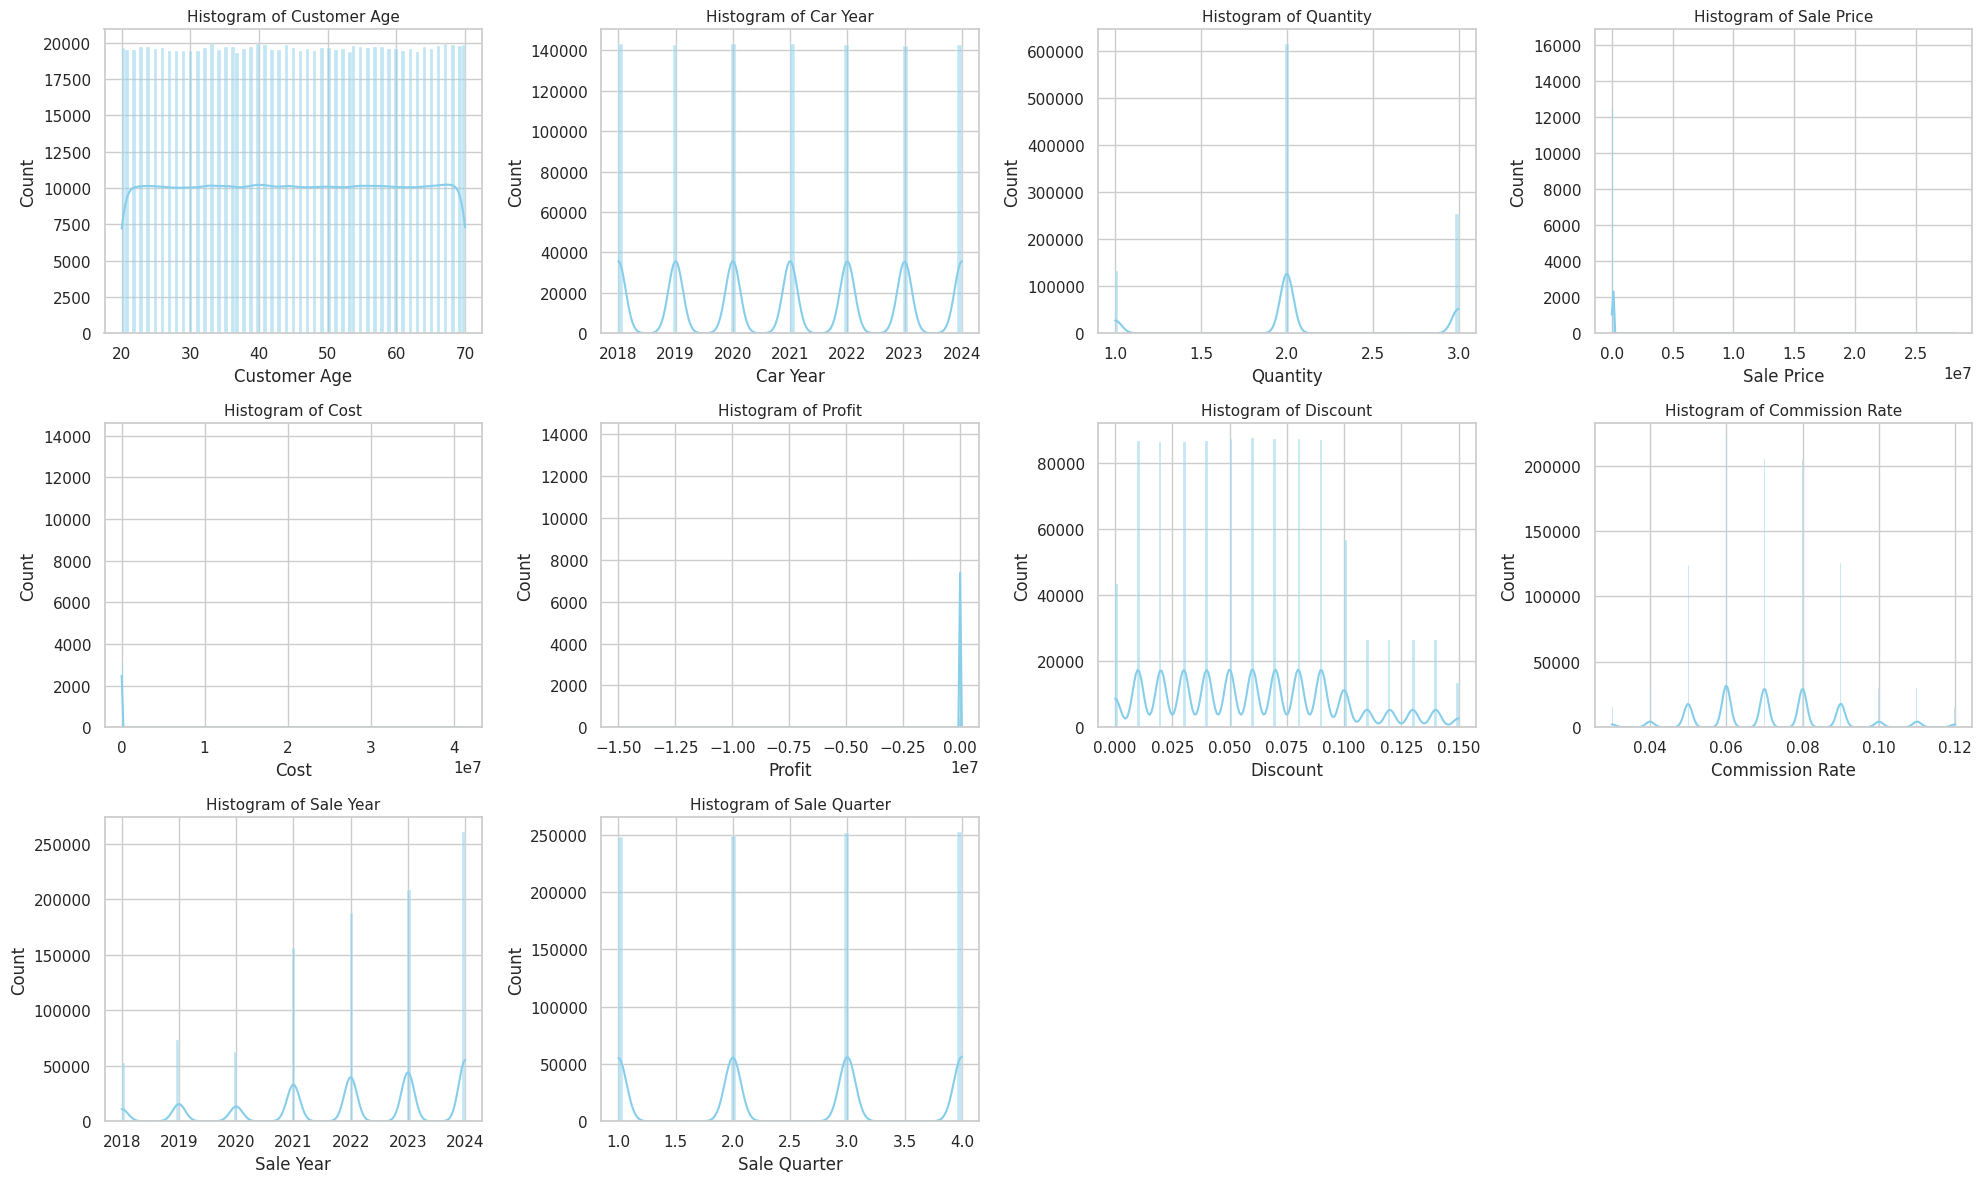

In [ ]:


sns.set(style="whitegrid")

fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for i, col in enumerate(num_features):
    ax = axes[i // 4, i % 4]
    sns.histplot(data[col], color="skyblue", kde=True, ax=ax)
    ax.set_title(f"Histogram of {col}", fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

for j in range(len(num_features), 12):
    fig.delaxes(axes[j // 4, j % 4])

plt.tight_layout()
plt.show()



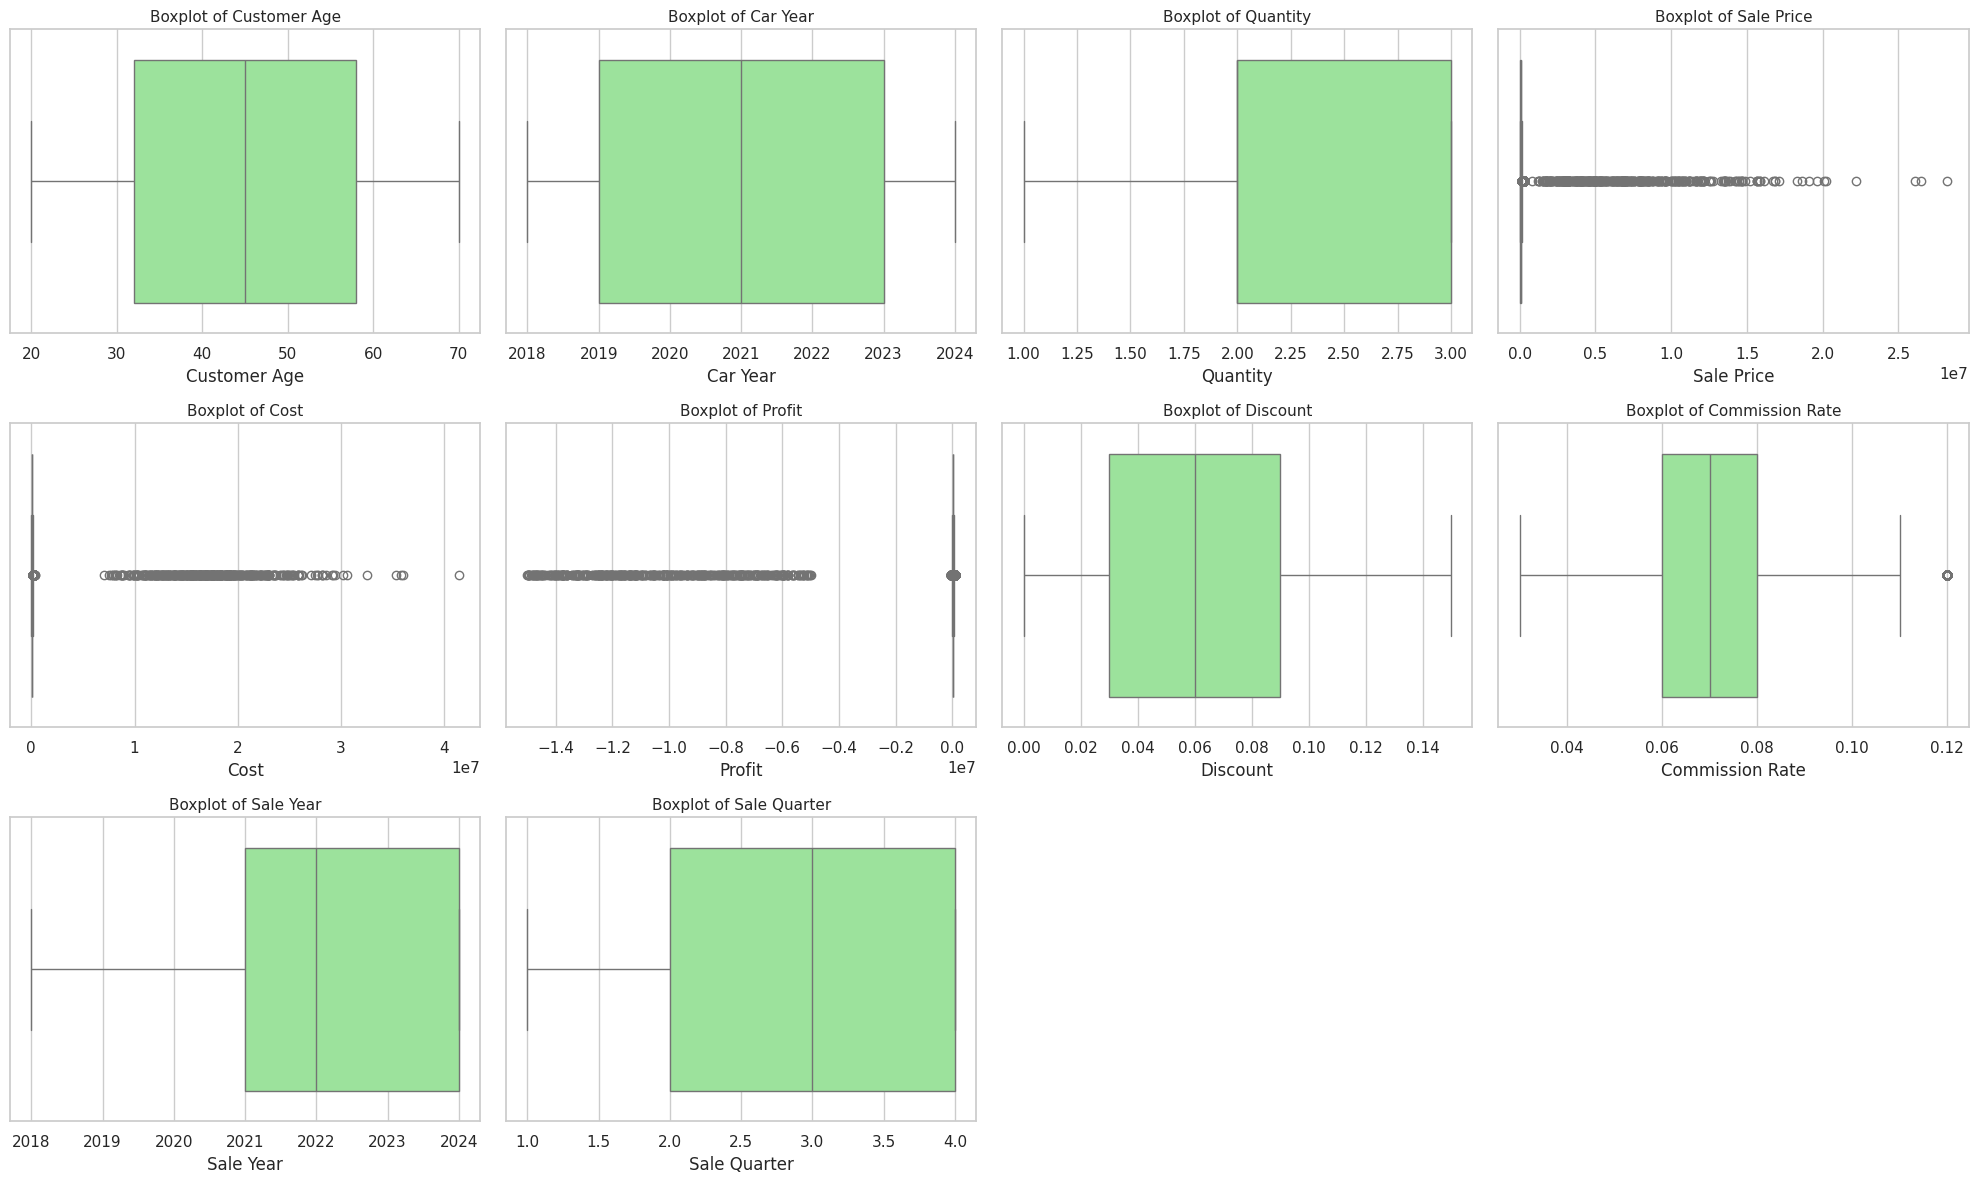

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for i, col in enumerate(num_features):
    ax = axes[i // 4, i % 4]
    sns.boxplot(x=data[col], color="lightgreen", ax=ax)
    ax.set_title(f"Boxplot of {col}", fontsize=11)
    ax.set_xlabel(col)

# Hide unused axes
for j in range(len(num_features), 12):
    fig.delaxes(axes[j // 4, j % 4])

plt.tight_layout()
plt.show()


## Feature engineering

In [ ]:

data['Date'] = pd.to_datetime(data['Date'])
data['Sale_Day'] = data['Date'].dt.day
data['Sale_Week'] = data['Date'].dt.isocalendar().week
data['Sale_Weekday'] = data['Date'].dt.weekday
data['Is_Weekend'] = data['Sale_Weekday'].isin([5,6]).astype(int)
data['Cumulative_Quantity_Model'] = data.groupby('Car Model')['Quantity'].cumsum()


## analysis after feature engineering

#### Correlation and Multicollinearity

<Axes: xlabel='Car Make', ylabel='Sale Price'>

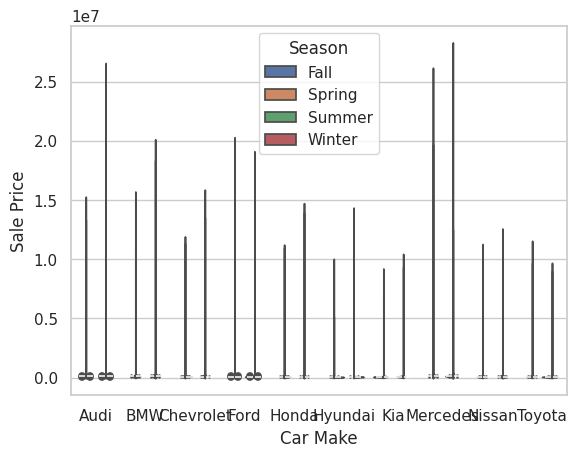

In [ ]:
sns.violinplot(x='Car Make', y='Sale Price', hue='Season', data=data, split=True)


In [ ]:
!pip install statsmodels


In [ ]:
### seasonality analysis

In [ ]:
data = data.sort_values('Date')


dates = data['Date'].reset_index(drop=True)

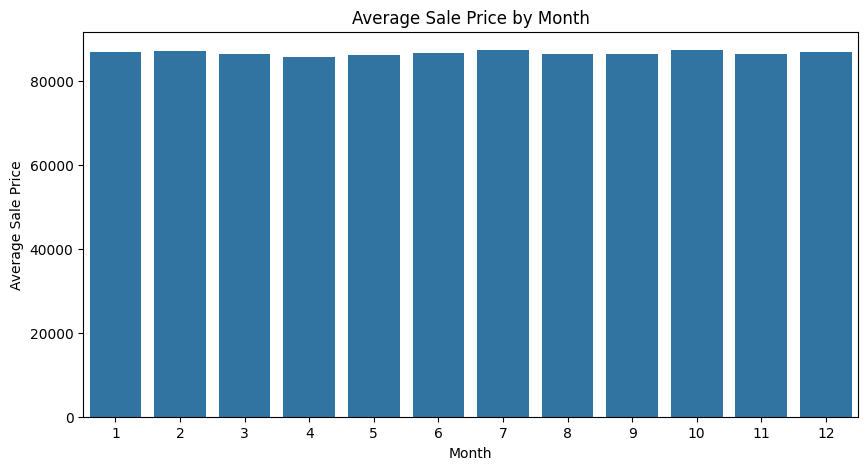

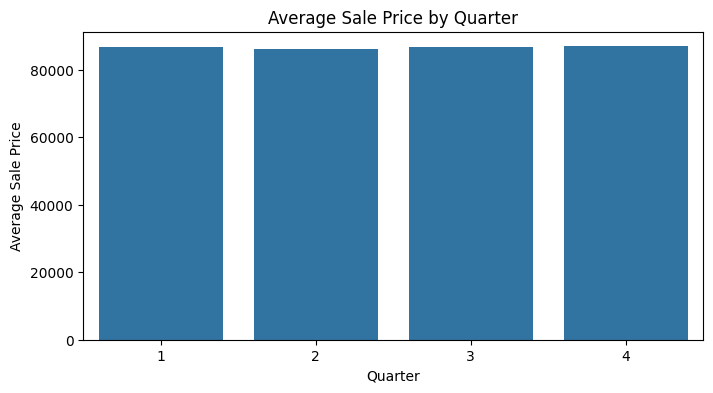

In [ ]:
# Monthly seasonality
monthly_avg = data.groupby(data['Date'].dt.month)['Sale Price'].mean()
plt.figure(figsize=(10,5))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values)
plt.title('Average Sale Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Sale Price')
plt.show()

# Quarterly seasonality
quarterly_avg = data.groupby(data['Date'].dt.quarter)['Sale Price'].mean()
plt.figure(figsize=(8,4))
sns.barplot(x=quarterly_avg.index, y=quarterly_avg.values)
plt.title('Average Sale Price by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average Sale Price')
plt.show()


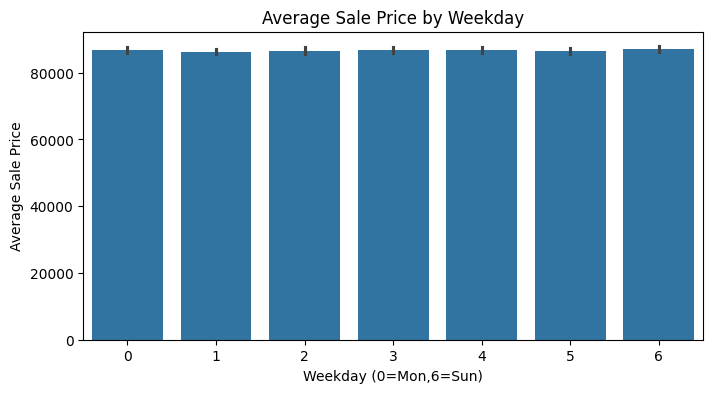

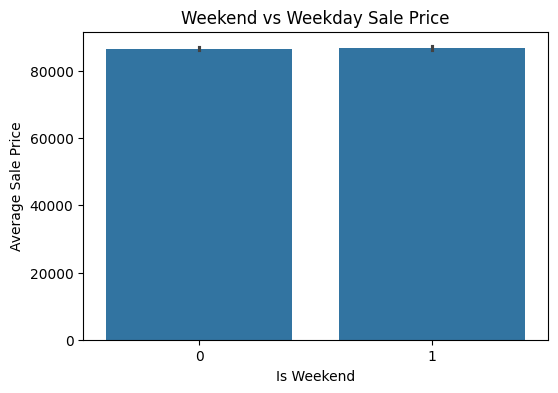

In [ ]:
data['Weekday'] = data['Date'].dt.weekday
data['Is_Weekend'] = data['Weekday'].isin([5,6]).astype(int)

plt.figure(figsize=(8,4))
sns.barplot(x='Weekday', y='Sale Price', data=data)
plt.title('Average Sale Price by Weekday')
plt.xlabel('Weekday (0=Mon,6=Sun)')
plt.ylabel('Average Sale Price')
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x='Is_Weekend', y='Sale Price', data=data)
plt.title('Weekend vs Weekday Sale Price')
plt.xlabel('Is Weekend')
plt.ylabel('Average Sale Price')
plt.show()


In [ ]:
#### . Seasonal Decomposition

In [ ]:
!pip install statsmodels


In [ ]:
import statsmodels.api as sm


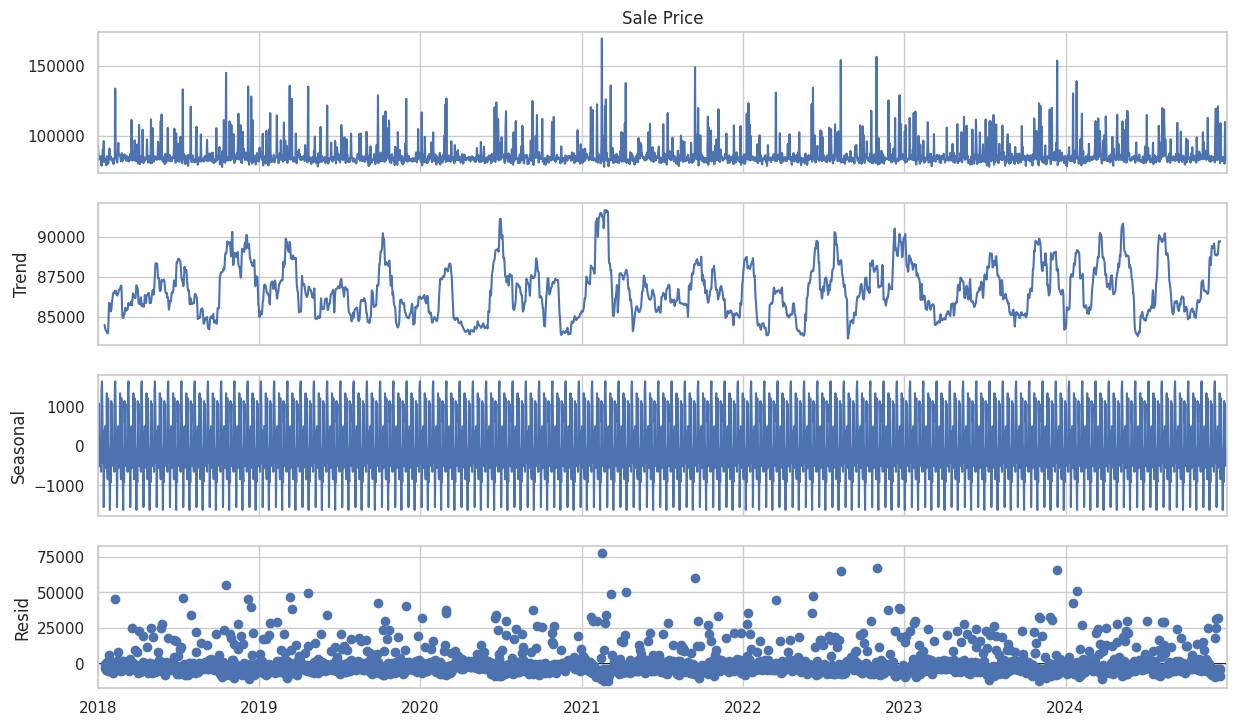

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])

# Daily aggregation
ts = data.groupby('Date')['Sale Price'].mean()

# Seasonal decomposition
decomposition = sm.tsa.seasonal_decompose(ts, model='additive', period=30)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.show()



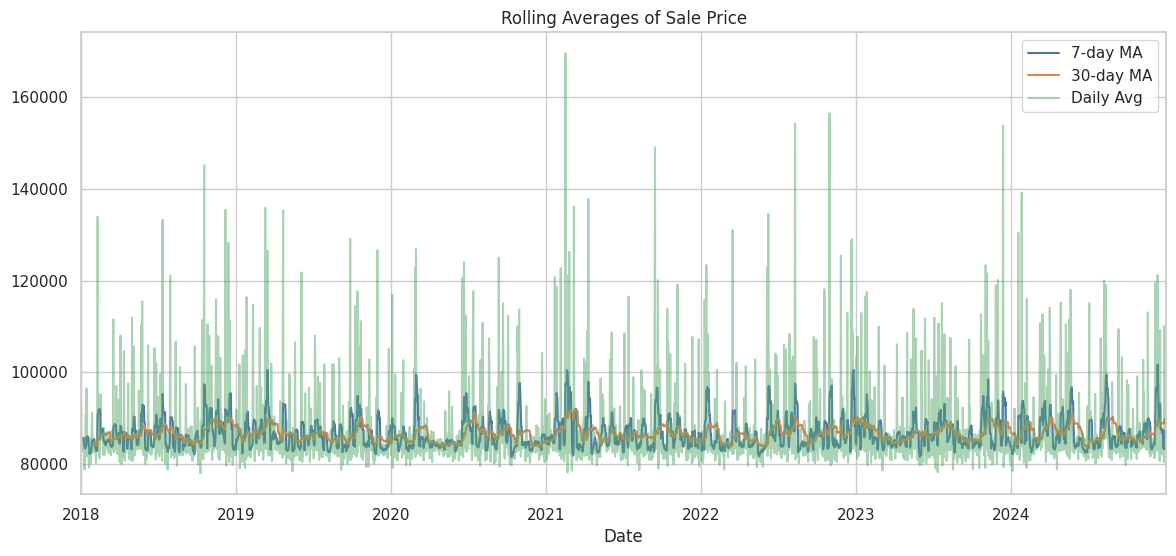

In [ ]:
plt.figure(figsize=(14,6))
ts.rolling(window=7).mean().plot(label='7-day MA')
ts.rolling(window=30).mean().plot(label='30-day MA')
ts.plot(alpha=0.5, label='Daily Avg')
plt.title('Rolling Averages of Sale Price')
plt.legend()
plt.show()


In [ ]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
# Drop columns to avoid leakage
X = data[numeric_cols].drop(columns=['Cost','Profit','Sale Price'])

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)



                     feature            VIF
0               Customer Age      10.346786
1                   Car Year  639704.121406
2                   Quantity      14.809936
3                   Discount       3.573341
4            Commission Rate      17.653444
5                  Sale Year  641694.668696
6               Sale Quarter       6.152825
7                 Is_Weekend       1.398335
8  Cumulative_Quantity_Model       4.077446


## Data Preprocesing

In [ ]:
data.columns

Index(['Date', 'Salesperson', 'Customer Age', 'Customer Gender', 'Car Make',
       'Car Model', 'Car Year', 'Quantity', 'Sale Price', 'Cost', 'Profit',
       'Discount', 'Payment Method', 'Commission Rate', 'Sales Region',
       'Sale Year', 'Sale Month', 'Sale Quarter', 'Day of Week', 'Season',
       'Sale_Day', 'Sale_Week', 'Sale_Weekday', 'Is_Weekend',
       'Cumulative_Quantity_Model', 'Weekday'],
      dtype='object')

In [ ]:

drop_cols = ['Cost', 'Profit', 'Sale Price', 'Car Year', 'Customer Age','Sale Year']
X = data.drop(columns=drop_cols)
y = data['Sale Price']
dates = data['Date']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# 1. Split first
train_df, test_df = train_test_split(
    data, test_size=0.2, shuffle=False
)

# 2. Select numeric cols
numeric_cols = train_df.select_dtypes(include=['float64','int64']).columns

# 3. Compute IQR on train only
Q1 = train_df[numeric_cols].quantile(0.25)
Q3 = train_df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

lower_limits = Q1 - 1.5 * IQR
upper_limits = Q3 + 1.5 * IQR

# 4. Remove outliers in train
for col in numeric_cols:
    train_df = train_df[
        (train_df[col] >= lower_limits[col]) &
        (train_df[col] <= upper_limits[col])
    ]

# 5. Clip test instead of dropping rows
for col in numeric_cols:
    test_df[col] = test_df[col].clip(lower_limits[col], upper_limits[col])

# 6. Now apply preprocessing


In [ ]:
target_col = "Sale Price"

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]


In [ ]:
numeric_features = [
    'Quantity',
    'Discount',
    'Commission Rate',
    'Sale Month',
    'Sale_Day',
    'Sale_Week',
    'Sale_Weekday',
    'Is_Weekend',
    'Cumulative_Quantity_Model',
    'Weekday'
]


In [ ]:
nominal_features = [
    'Salesperson',
    'Customer Gender',
    'Car Make',
    'Car Model',
    'Payment Method',
    'Sales Region',
    'Season',
    'Day of Week'
]


In [ ]:
ordinal_features = [
    'Sale Quarter'
]


In [ ]:

numeric_features = ['Quantity', 'Discount', 'Commission Rate', 'Sale Month',
                    'Sale_Day', 'Sale_Week', 'Sale_Weekday', 'Is_Weekend',
                    'Cumulative_Quantity_Model', 'Weekday']

for col in numeric_features:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')


In [ ]:


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('nom', nominal_transformer, nominal_features),
    ('ord', ordinal_transformer, ordinal_features)
])


In [ ]:
# Fit only on training set
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test set
X_test_processed = preprocessor.transform(X_test)

print("X_train shape:", X_train_processed.shape)
print("X_test shape:", X_test_processed.shape)


X_train shape: (755540, 186)
X_test shape: (200134, 186)


## Model Building

In [ ]:
#### Define Sequence Creation Function

In [ ]:


def create_sequences(X, y, seq_length=60):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)


In [ ]:
X_train_dense = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_test_dense  = X_test_processed.toarray()  if hasattr(X_test_processed, "toarray") else X_test_processed


In [ ]:
seq_length = 60   # lookback window

X_train_seq, y_train_seq = create_sequences(
    X_train_dense,
    y_train.values,
    seq_length
)

X_test_seq, y_test_seq = create_sequences(
    X_test_dense,
    y_test.values,
    seq_length
)

print("X_train_seq:", X_train_seq.shape)
print("X_test_seq :", X_test_seq.shape)


In [ ]:
dates = dates.reset_index(drop=True)

# matching dates for test sequences
test_start_index = len(X_train_dense)
dates_test = dates.iloc[test_start_index:]
dates_test_seq = dates_test[seq_length:].reset_index(drop=True)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

model = Sequential([
    GRU(128, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.3),

    GRU(64),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 128)        │       121,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,705 (627.75 KB)

 Trainable params: 160,705 (627.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=150,
    batch_size=1000,
    verbose=1
)


In [ ]:
loss, mae = model.evaluate(X_test_seq, y_test_seq)
print(f"\nTest MAE: {mae:.4f}")


In [ ]:
y_pred = model.predict(X_test_seq)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(dates_test_seq, y_test_seq, label='Actual', color='blue')
plt.plot(dates_test_seq, y_pred, label='Predicted', color='red', alpha=0.7)
plt.title("GRU Forecast: Actual vs Predicted Sale Price")
plt.xlabel("Date")
plt.ylabel("Sale Price")
plt.xticks(rotation=45)
plt.legend()
plt.show()


In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test_seq, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red', alpha=0.7)
plt.title("GRU Forecast: Actual vs Predicted Sale Price")
plt.xlabel("Test Sample Index")
plt.ylabel("Sale Price")
plt.legend()
plt.show()
